# ST-GCN Baseline for WLASL Sign Recognition Using MediaPipe Pose and Hand Landmarks

This notebook creates the **next model after Random Forest, HMM, and LSTM**.

The earlier models used landmark data in different ways:

| Model | How it used landmarks | Main weakness |
|---|---|---|
| Random Forest | Summarized each video using mean, standard deviation, minimum, and maximum | Loses motion order |
| HMM | Used landmark sequences | Too simple for complex signing movement |
| LSTM | Used landmark sequences as flat vectors | Learns time, but does not understand joint connections |
| **ST-GCN** | Uses landmarks as a spatial-temporal graph | Better represents body/hand movement structure |

## What ST-GCN means

**ST-GCN** means:

```text
Spatial Temporal Graph Convolutional Network
```

It is useful for sign language because signs are made from:

- hand joint movement
- body posture
- arm movement
- timing
- relationship between connected joints

Instead of treating landmarks as one long flat vector, this notebook treats them as a graph:

```text
landmark nodes + physical joint connections + movement over time
```

## What this notebook does

1. Loads WLASL using FiftyOne.
2. Selects the same fixed classes used in the Random Forest, HMM, and LSTM notebooks.
3. Extracts MediaPipe pose and hand landmarks.
4. Converts every video into a tensor with shape:

```text
time_steps × graph_nodes × coordinates
```

5. Builds a graph adjacency matrix that connects body and hand joints.
6. Trains a simple ST-GCN-like PyTorch model.
7. Evaluates accuracy, precision, recall, F1-score, classification report, and confusion matrix.
8. Saves the model, encoder, metadata, and comparison-ready metrics.

## Important note

This is a **baseline ST-GCN implementation**, designed for thesis experimentation and model comparison.

It is not yet the final production KSL healthcare model.

## 1. Install PyTorch if missing

If you are using the Docker environment and PyTorch is already installed, skip this cell.

This notebook uses a custom PyTorch ST-GCN-like implementation, so we do **not** need `torch-geometric`.

In [1]:
# Uncomment only if torch is missing
# import sys
# !{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

## 2. Import libraries

These libraries are used for:

- dataset loading
- video processing
- landmark extraction
- graph feature construction
- PyTorch model training
- evaluation and reporting

In [2]:
import os
import sys
import json
import random
import logging
from pathlib import Path
from datetime import datetime
from collections import Counter

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

import fiftyone as fo
import fiftyone.utils.huggingface as fouh
import mediapipe as mp

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("FiftyOne database URI:", os.environ.get("FIFTYONE_DATABASE_URI"))
print("MediaPipe version:", getattr(mp, "__version__", "unknown"))
print("MediaPipe has solutions:", hasattr(mp, "solutions"))
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.11.15 (main, May 19 2026, 23:49:45) [GCC 14.2.0]
Python executable: /usr/local/bin/python
FiftyOne database URI: mongodb://mongo:27017
MediaPipe version: 0.10.21
MediaPipe has solutions: True
Torch version: 2.12.0+cpu
CUDA available: False


## 3. Configure project folders and logging

Outputs are saved in:

```text
/workspace/dataset/ksl_project_data/
```

This folder should be mounted from your Docker project, so the saved files remain available even after stopping Docker.

In [3]:
PROJECT_DIR = Path("/workspace/dataset/ksl_project_data").resolve()

# Fallback if running outside Docker
if not Path("/workspace/dataset").exists():
    PROJECT_DIR = Path("ksl_project_data").resolve()

LOG_DIR = PROJECT_DIR / "logs"
FEATURE_DIR = PROJECT_DIR / "features"
MODEL_DIR = PROJECT_DIR / "models"

for folder in [PROJECT_DIR, LOG_DIR, FEATURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

log_file = LOG_DIR / f"stgcn_wlasl_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler(sys.stdout),
    ],
    force=True,
)

logger = logging.getLogger(__name__)
logger.info("ST-GCN notebook started")
logger.info(f"Project directory: {PROJECT_DIR}")

print("Project directory:", PROJECT_DIR)
print("Log file:", log_file)

2026-06-05 11:41:29,759 | INFO | ST-GCN notebook started
2026-06-05 11:41:29,761 | INFO | Project directory: /workspace/dataset/ksl_project_data
Project directory: /workspace/dataset/ksl_project_data
Log file: /workspace/dataset/ksl_project_data/logs/stgcn_wlasl_20260605_114129.log


## 4. Set random seed

This makes results more reproducible.

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 5. Load WLASL dataset

This loads the same WLASL dataset used in the previous notebooks.

The notebook first checks whether WLASL already exists in FiftyOne. If it does, it loads the local version. If not, it loads from the Hugging Face/FiftyOne hub.

In [5]:
DATASET_NAME = "Voxel51/WLASL"

if DATASET_NAME in fo.list_datasets():
    logger.info("Loading existing local WLASL dataset")
    dataset = fo.load_dataset(DATASET_NAME)
else:
    logger.info("Loading WLASL from Hugging Face/FiftyOne hub")
    dataset = fouh.load_from_hub(DATASET_NAME, persistent=True)

dataset.persistent = True

logger.info(f"Dataset loaded: {dataset.name}")
logger.info(f"Total samples: {len(dataset)}")

print("Dataset:", dataset.name)
print("Total samples:", len(dataset))
print("Field schema:", dataset.get_field_schema())

2026-06-05 11:42:37,377 | INFO | Loading existing local WLASL dataset
2026-06-05 11:42:37,449 | INFO | Dataset loaded: Voxel51/WLASL
2026-06-05 11:42:37,452 | INFO | Total samples: 11980
Dataset: Voxel51/WLASL
Total samples: 11980
Field schema: OrderedDict([('id', <fiftyone.core.fields.ObjectIdField object at 0x7f84531d4f50>), ('filepath', <fiftyone.core.fields.StringField object at 0x7f84537e0a50>), ('tags', <fiftyone.core.fields.ListField object at 0x7f8453861dd0>), ('metadata', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f845452bb90>), ('created_at', <fiftyone.core.fields.DateTimeField object at 0x7f84537af810>), ('last_modified_at', <fiftyone.core.fields.DateTimeField object at 0x7f8453164710>), ('bounding_box', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f84e1488bd0>), ('gloss', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f84532c6290>)])


## 6. Label extraction helper

Different WLASL/FiftyOne versions may store labels using different field names.

This helper checks common fields such as:

- `ground_truth`
- `label`
- `word`
- `gloss`

It returns the sign label for each video sample.

In [7]:
def get_label_from_sample(sample):
    candidate_fields = ["ground_truth", "label", "labels", "classification", "word", "gloss"]

    for field in candidate_fields:
        if field in sample:
            value = sample[field]

            if value is None:
                continue

            if hasattr(value, "label"):
                return value.label

            if isinstance(value, str):
                return value

    for field in sample.field_names:
        value = sample[field]

        if hasattr(value, "label"):
            return value.label

        if field.lower() in ["word", "gloss", "label"] and isinstance(value, str):
            return value

    return None


labels = []
missing_labels = 0

for sample in dataset:
    label = get_label_from_sample(sample)

    if label is None:
        missing_labels += 1
    else:
        labels.append(label)

label_counts = Counter(labels)

print("Samples with labels:", len(labels))
print("Samples missing labels:", missing_labels)
print("Unique labels:", len(label_counts))
print("Top 20 labels:")

for label, count in label_counts.most_common(20):
    print(label, count)

Samples with labels: 11980
Samples missing labels: 0
Unique labels: 2000
Top 20 labels:
before 16
cool 16
thin 16
drink 15
go 15
computer 14
cousin 14
help 14
who 14
accident 13
bed 13
bowling 13
candy 13
short 13
tall 13
thanksgiving 13
trade 13
basketball 12
call 12
change 12


## 7. Select fixed classes for fair comparison

To compare fairly with Random Forest, HMM, and LSTM, we use the same classes:

```text
before, computer, cool, cousin, drink
```

These are not healthcare signs. They are benchmark labels from WLASL used to test whether the model pipeline works.

Later, when you collect or validate Kenyan Sign Language healthcare phrases, these labels will be replaced by healthcare-specific KSL phrases.

In [8]:
FIXED_CLASSES = ["before", "computer", "cool", "cousin", "drink"]
MAX_SAMPLES_PER_CLASS = 40

selected_labels_set = set(FIXED_CLASSES)
selected_samples = []
per_class_counter = Counter()

for sample in dataset:
    label = get_label_from_sample(sample)

    if label in selected_labels_set and per_class_counter[label] < MAX_SAMPLES_PER_CLASS:
        if sample.filepath and Path(sample.filepath).exists():
            selected_samples.append(sample)
            per_class_counter[label] += 1

logger.info(f"Selected classes: {FIXED_CLASSES}")
logger.info(f"Selected usable video samples: {len(selected_samples)}")

print("Selected classes:", FIXED_CLASSES)
print("Selected usable videos:", len(selected_samples))
print("Per-class counts:", per_class_counter)

2026-06-05 11:43:50,339 | INFO | Selected classes: ['before', 'computer', 'cool', 'cousin', 'drink']
2026-06-05 11:43:50,341 | INFO | Selected usable video samples: 67
Selected classes: ['before', 'computer', 'cool', 'cousin', 'drink']
Selected usable videos: 67
Per-class counts: Counter({'before': 15, 'computer': 14, 'cool': 13, 'cousin': 13, 'drink': 12})


## 8. MediaPipe Holistic setup

For ST-GCN, we focus on:

- body/pose landmarks
- left hand landmarks
- right hand landmarks

We intentionally exclude face landmarks in this baseline because face landmarks are very many. Including all 468 face nodes makes the graph large and slow.

The ST-GCN graph in this notebook uses:

```text
33 pose nodes + 21 left hand nodes + 21 right hand nodes = 75 nodes
```

Each node has:

```text
x, y, z
```

So each video frame becomes:

```text
75 nodes × 3 coordinates
```

In [9]:
try:
    mp_holistic = mp.solutions.holistic
    print("Using mp.solutions.holistic")
except AttributeError:
    from mediapipe.python.solutions import holistic as mp_holistic
    print("Using mediapipe.python.solutions.holistic fallback")

POSE_LANDMARKS = 33
HAND_LANDMARKS = 21
FEATURES_PER_NODE = 3

NUM_POSE_NODES = 33
NUM_LEFT_HAND_NODES = 21
NUM_RIGHT_HAND_NODES = 21
NUM_GRAPH_NODES = NUM_POSE_NODES + NUM_LEFT_HAND_NODES + NUM_RIGHT_HAND_NODES

LEFT_HAND_OFFSET = NUM_POSE_NODES
RIGHT_HAND_OFFSET = NUM_POSE_NODES + NUM_LEFT_HAND_NODES

print("Number of graph nodes:", NUM_GRAPH_NODES)
print("Coordinates per node:", FEATURES_PER_NODE)

Using mp.solutions.holistic
Number of graph nodes: 75
Coordinates per node: 3


## 9. Build the graph adjacency matrix

This is the key difference between LSTM and ST-GCN.

LSTM sees a flat vector like this:

```text
[x1, y1, z1, x2, y2, z2, ...]
```

ST-GCN sees a connected graph:

```text
node 1 connected to node 2
node 2 connected to node 3
hand joint connected to next hand joint
shoulder connected to elbow
elbow connected to wrist
```

The adjacency matrix tells the model which landmarks are physically connected.

In [10]:
# Approximate MediaPipe pose skeleton connections
POSE_EDGES = [
    (11, 12),  # shoulders
    (11, 13), (13, 15),  # left arm
    (12, 14), (14, 16),  # right arm
    (11, 23), (12, 24),  # torso
    (23, 24),  # hips
    (23, 25), (25, 27),  # left leg
    (24, 26), (26, 28),  # right leg
    (0, 1), (1, 2), (2, 3), (3, 7),  # face left side
    (0, 4), (4, 5), (5, 6), (6, 8),  # face right side
    (9, 10),  # mouth
]

# MediaPipe hand skeleton connections
HAND_EDGES_BASE = [
    (0, 1), (1, 2), (2, 3), (3, 4),        # thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # index
    (0, 9), (9, 10), (10, 11), (11, 12),   # middle
    (0, 13), (13, 14), (14, 15), (15, 16), # ring
    (0, 17), (17, 18), (18, 19), (19, 20), # pinky
    (5, 9), (9, 13), (13, 17),             # palm links
]


def build_adjacency_matrix(num_nodes=NUM_GRAPH_NODES):
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)

    # self-connections
    for i in range(num_nodes):
        A[i, i] = 1.0

    # pose connections
    for i, j in POSE_EDGES:
        A[i, j] = 1.0
        A[j, i] = 1.0

    # left hand connections
    for i, j in HAND_EDGES_BASE:
        li = LEFT_HAND_OFFSET + i
        lj = LEFT_HAND_OFFSET + j
        A[li, lj] = 1.0
        A[lj, li] = 1.0

    # right hand connections
    for i, j in HAND_EDGES_BASE:
        ri = RIGHT_HAND_OFFSET + i
        rj = RIGHT_HAND_OFFSET + j
        A[ri, rj] = 1.0
        A[rj, ri] = 1.0

    # connect hands to wrists
    # MediaPipe pose: 15 = left wrist, 16 = right wrist
    A[15, LEFT_HAND_OFFSET + 0] = 1.0
    A[LEFT_HAND_OFFSET + 0, 15] = 1.0

    A[16, RIGHT_HAND_OFFSET + 0] = 1.0
    A[RIGHT_HAND_OFFSET + 0, 16] = 1.0

    return A


def normalize_adjacency(A):
    degree = np.sum(A, axis=1)
    degree[degree == 0] = 1.0

    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt

    return A_norm.astype(np.float32)


A = build_adjacency_matrix()
A_norm = normalize_adjacency(A)

print("Adjacency matrix shape:", A_norm.shape)
print("Number of graph connections:", int(A.sum()))

Adjacency matrix shape: (75, 75)
Number of graph connections: 213


## 10. Landmark extraction for graph sequences

This function converts each video into:

```text
time_steps × 75 nodes × 3 coordinates
```

For every frame:

1. Read video frame
2. Run MediaPipe Holistic
3. Extract pose landmarks
4. Extract left hand landmarks
5. Extract right hand landmarks
6. Combine into one graph frame

In [11]:
def landmarks_to_nodes(landmarks, expected_count):
    if landmarks is None:
        return np.zeros((expected_count, FEATURES_PER_NODE), dtype=np.float32)

    nodes = []

    for lm in landmarks.landmark[:expected_count]:
        nodes.append([lm.x, lm.y, lm.z])

    if len(nodes) < expected_count:
        missing = expected_count - len(nodes)
        nodes.extend([[0.0, 0.0, 0.0]] * missing)

    return np.array(nodes[:expected_count], dtype=np.float32)


def extract_video_graph_sequence(video_path, max_frames=60, frame_stride=2):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    sequence = []
    frame_index = 0

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False,
        refine_face_landmarks=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as holistic:

        while cap.isOpened() and len(sequence) < max_frames:
            success, frame = cap.read()

            if not success:
                break

            if frame_index % frame_stride != 0:
                frame_index += 1
                continue

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)

            pose_nodes = landmarks_to_nodes(results.pose_landmarks, NUM_POSE_NODES)
            left_hand_nodes = landmarks_to_nodes(results.left_hand_landmarks, NUM_LEFT_HAND_NODES)
            right_hand_nodes = landmarks_to_nodes(results.right_hand_landmarks, NUM_RIGHT_HAND_NODES)

            graph_frame = np.concatenate(
                [pose_nodes, left_hand_nodes, right_hand_nodes],
                axis=0,
            )

            sequence.append(graph_frame)
            frame_index += 1

    cap.release()

    if len(sequence) == 0:
        return None

    return np.stack(sequence).astype(np.float32)


def pad_or_truncate_graph_sequence(sequence, target_length=60):
    # sequence shape: T x V x C
    T, V, C = sequence.shape

    if T >= target_length:
        return sequence[:target_length]

    padded = np.zeros((target_length, V, C), dtype=np.float32)
    padded[:T] = sequence

    return padded

## 11. Extract or load cached ST-GCN graph sequences

MediaPipe extraction can take time.

This cell caches extracted graph sequences to avoid repeating video processing every time.

In [12]:
STGCN_SEQUENCE_CACHE = FEATURE_DIR / "wlasl_stgcn_graph_sequences_fixed_classes.joblib"

MAX_FRAMES = 60
FRAME_STRIDE = 2

if STGCN_SEQUENCE_CACHE.exists():
    logger.info(f"Loading cached ST-GCN graph sequences from {STGCN_SEQUENCE_CACHE}")
    cached = joblib.load(STGCN_SEQUENCE_CACHE)
    X_graph = cached["X_graph"]
    y_labels = cached["y_labels"]
else:
    logger.info("Extracting ST-GCN graph sequences from videos")

    X_list = []
    y_list = []
    failed = []

    for index, sample in enumerate(selected_samples, start=1):
        label = get_label_from_sample(sample)

        try:
            sequence = extract_video_graph_sequence(
                sample.filepath,
                max_frames=MAX_FRAMES,
                frame_stride=FRAME_STRIDE,
            )

            if sequence is None:
                failed.append((sample.filepath, "No landmarks extracted"))
                continue

            fixed_sequence = pad_or_truncate_graph_sequence(sequence, target_length=MAX_FRAMES)

            X_list.append(fixed_sequence)
            y_list.append(label)

            if index % 10 == 0:
                logger.info(f"Processed {index}/{len(selected_samples)} videos")

        except Exception as exc:
            failed.append((sample.filepath, str(exc)))
            logger.warning(f"Failed sample {sample.filepath}: {exc}")

    X_graph = np.stack(X_list).astype(np.float32)
    y_labels = np.array(y_list)

    joblib.dump(
        {
            "X_graph": X_graph,
            "y_labels": y_labels,
            "fixed_classes": FIXED_CLASSES,
            "max_frames": MAX_FRAMES,
            "frame_stride": FRAME_STRIDE,
            "num_graph_nodes": NUM_GRAPH_NODES,
        },
        STGCN_SEQUENCE_CACHE,
    )

    logger.info(f"Saved ST-GCN graph cache: {STGCN_SEQUENCE_CACHE}")
    logger.info(f"Failed videos: {len(failed)}")

print("X_graph shape:", X_graph.shape)
print("y_labels shape:", y_labels.shape)
print("Classes:", sorted(set(y_labels)))
print("Expected shape format: samples x time x nodes x coordinates")

2026-06-05 11:45:45,579 | INFO | Extracting ST-GCN graph sequences from videos


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780659949.690198    4996 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780659953.888452    4996 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780659954.262142    5000 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
W0000 00:00:1780659954.577991    5002 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780659954.612602    4995 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:

2026-06-05 11:47:01,257 | INFO | Processed 10/67 videos


W0000 00:00:1780660021.411355    5172 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660021.844605    5172 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660021.848647    5175 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660021.848656    5173 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660021.850375    5171 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660021.864273    5175 inference_feedback_manager.cc:114] Feedback manager 

2026-06-05 11:47:43,528 | INFO | Processed 20/67 videos


...

2026-06-05 11:48:50,010 | INFO | Processed 50/67 videos


W0000 00:00:1780660130.120553    5819 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660130.146646    5823 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660130.150222    5822 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660130.150634    5823 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660130.151115    5826 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660130.159054    5822 inference_feedback_manager.cc:114] Feedback manager 

2026-06-05 11:49:11,930 | INFO | Processed 60/67 videos


W0000 00:00:1780660152.060541    5979 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660152.139162    5979 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660152.142768    5981 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660152.143672    5980 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660152.144905    5979 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780660152.155094    5980 inference_feedback_manager.cc:114] Feedback manager 

2026-06-05 11:49:24,498 | INFO | Saved ST-GCN graph cache: /workspace/dataset/ksl_project_data/features/wlasl_stgcn_graph_sequences_fixed_classes.joblib
2026-06-05 11:49:24,501 | INFO | Failed videos: 0
X_graph shape: (67, 60, 75, 3)
y_labels shape: (67,)
Classes: ['before', 'computer', 'cool', 'cousin', 'drink']
Expected shape format: samples x time x nodes x coordinates


## 12. Encode labels and split train/test data

We split by video sample, not by frame.

This prevents information leakage from the same video appearing in both training and test sets.

In [13]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

X_train, X_test, y_train, y_test = train_test_split(
    X_graph,
    y_encoded,
    test_size=0.25,
    random_state=SEED,
    stratify=y_encoded,
)

print("Training videos:", X_train.shape[0])
print("Testing videos:", X_test.shape[0])
print("Sequence length:", X_train.shape[1])
print("Graph nodes:", X_train.shape[2])
print("Coordinates:", X_train.shape[3])

print("Classes:")
for idx, label in enumerate(label_encoder.classes_):
    print(idx, "=>", label)

Training videos: 50
Testing videos: 17
Sequence length: 60
Graph nodes: 75
Coordinates: 3
Classes:
0 => before
1 => computer
2 => cool
3 => cousin
4 => drink


## 13. Scale coordinate features

ST-GCN training is more stable when coordinates are normalized.

We fit the scaler on training coordinates only, then apply it to both train and test.

In [14]:
scaler = StandardScaler()

N_train, T, V, C = X_train.shape
N_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, C)
X_test_2d = X_test.reshape(-1, C)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(N_train, T, V, C).astype(np.float32)
X_test_scaled = scaler.transform(X_test_2d).reshape(N_test, T, V, C).astype(np.float32)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (50, 60, 75, 3)
Scaled test shape: (17, 60, 75, 3)


## 14. Prepare PyTorch Dataset and DataLoader

PyTorch convolution layers expect channel-first format.

We convert data from:

```text
N × T × V × C
```

to:

```text
N × C × T × V
```

Where:

- N = number of videos
- C = coordinate channels, x/y/z
- T = time steps
- V = graph nodes

In [15]:
class GraphSequenceDataset(Dataset):
    def __init__(self, X, y):
        # Convert N x T x V x C to N x C x T x V
        X = np.transpose(X, (0, 3, 1, 2))

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 8

train_dataset = GraphSequenceDataset(X_train_scaled, y_train)
test_dataset = GraphSequenceDataset(X_test_scaled, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

A_tensor = torch.tensor(A_norm, dtype=torch.float32).to(device)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))
print("Adjacency tensor:", A_tensor.shape)

Train batches: 7
Test batches: 3
Adjacency tensor: torch.Size([75, 75])


## 15. Define a simple ST-GCN block

Each ST-GCN block does two things:

### 1. Spatial graph convolution

This mixes information between connected landmarks using the adjacency matrix.

Example:

```text
wrist node receives information from connected hand/arm nodes
```

### 2. Temporal convolution

This learns movement patterns across frames.

Example:

```text
how the wrist moves from frame 1 to frame 60
```

In [16]:
class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, A, temporal_kernel_size=9, dropout=0.2):
        super().__init__()

        self.register_buffer("A", A)

        padding = (temporal_kernel_size - 1) // 2

        self.spatial_linear = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=(1, 1),
        )

        self.temporal_conv = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=(temporal_kernel_size, 1),
                padding=(padding, 0),
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        if in_channels != out_channels:
            self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1))
        else:
            self.residual = nn.Identity()

    def forward(self, x):
        # x shape: N x C x T x V

        # Graph propagation:
        # For every node, mix features from connected nodes using adjacency matrix.
        x_graph = torch.einsum("nctv,vw->nctw", x, self.A)

        # Channel transformation
        x_graph = self.spatial_linear(x_graph)

        # Temporal convolution
        out = self.temporal_conv(x_graph)

        # Residual connection
        res = self.residual(x)

        return out + res

## 16. Define the ST-GCN classifier

The full model uses several ST-GCN blocks.

The flow is:

```text
graph sequence
→ ST-GCN block 1
→ ST-GCN block 2
→ ST-GCN block 3
→ global average pooling
→ fully connected classifier
→ sign class prediction
```

In [17]:
class SimpleSTGCNClassifier(nn.Module):
    def __init__(self, num_classes, A, in_channels=3, dropout=0.3):
        super().__init__()

        self.block1 = STGCNBlock(in_channels, 64, A, dropout=dropout)
        self.block2 = STGCNBlock(64, 128, A, dropout=dropout)
        self.block3 = STGCNBlock(128, 128, A, dropout=dropout)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x shape: N x C x T x V
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.pool(x)

        return self.classifier(x)


NUM_CLASSES = len(label_encoder.classes_)

model = SimpleSTGCNClassifier(
    num_classes=NUM_CLASSES,
    A=A_tensor,
    in_channels=FEATURES_PER_NODE,
    dropout=0.3,
).to(device)

print(model)

SimpleSTGCNClassifier(
  (block1): STGCNBlock(
    (spatial_linear): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
    (temporal_conv): Sequential(
      (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(9, 1), stride=(1, 1), padding=(4, 0))
      (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
    )
    (residual): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (block2): STGCNBlock(
    (spatial_linear): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    (temporal_conv): Sequential(
      (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(9, 1), stride=(1, 1), padding=(4, 0))
      (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_run

## 17. Train the ST-GCN model

Because the dataset subset is small, this model may overfit quickly.

Watch the difference between:

- training accuracy
- test accuracy

If training accuracy rises but test accuracy stays low, the model is overfitting.

In [18]:
EPOCHS = 30
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}


def run_epoch(loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y_batch.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    avg_accuracy = accuracy_score(all_targets, all_preds)

    return avg_loss, avg_accuracy


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, optimizer=optimizer)
    test_loss, test_acc = run_epoch(test_loader, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

Epoch 01/30 | Train Loss: 1.7572 | Train Acc: 0.1400 | Test Loss: 1.6027 | Test Acc: 0.2353
Epoch 02/30 | Train Loss: 1.5078 | Train Acc: 0.2800 | Test Loss: 1.6729 | Test Acc: 0.1176
Epoch 03/30 | Train Loss: 1.4640 | Train Acc: 0.4000 | Test Loss: 1.6699 | Test Acc: 0.1765
Epoch 04/30 | Train Loss: 1.4101 | Train Acc: 0.4200 | Test Loss: 1.6423 | Test Acc: 0.2941
Epoch 05/30 | Train Loss: 1.3473 | Train Acc: 0.3600 | Test Loss: 1.6528 | Test Acc: 0.2941
Epoch 06/30 | Train Loss: 1.3751 | Train Acc: 0.3400 | Test Loss: 1.5844 | Test Acc: 0.2353
Epoch 07/30 | Train Loss: 1.2754 | Train Acc: 0.4800 | Test Loss: 1.6298 | Test Acc: 0.1765
Epoch 08/30 | Train Loss: 1.3057 | Train Acc: 0.4600 | Test Loss: 1.5358 | Test Acc: 0.3529
Epoch 09/30 | Train Loss: 1.1991 | Train Acc: 0.5000 | Test Loss: 1.5457 | Test Acc: 0.1765
Epoch 10/30 | Train Loss: 1.1907 | Train Acc: 0.5200 | Test Loss: 1.6021 | Test Acc: 0.1765
Epoch 11/30 | Train Loss: 1.1782 | Train Acc: 0.5400 | Test Loss: 1.6063 | Test 

## 18. Plot training curves

These plots help interpret whether the model is learning or overfitting.

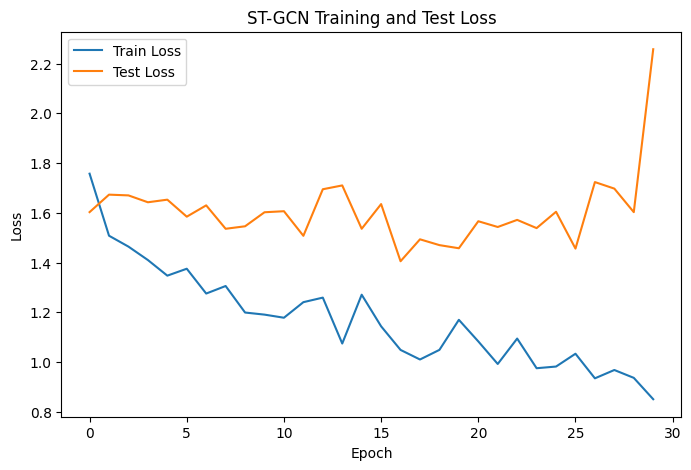

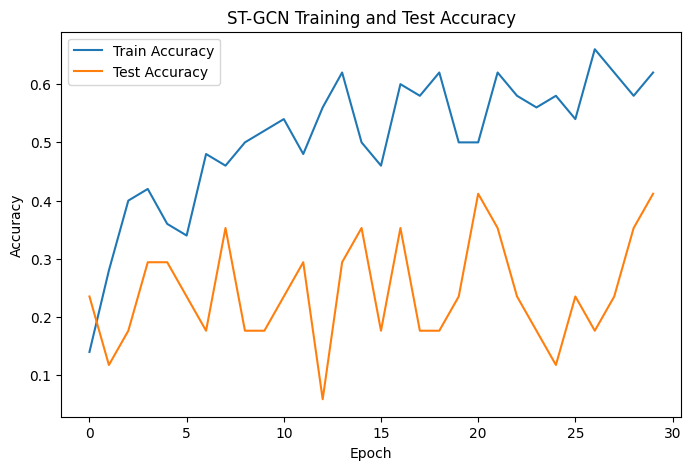

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ST-GCN Training and Test Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_accuracy"], label="Train Accuracy")
plt.plot(history["test_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ST-GCN Training and Test Accuracy")
plt.legend()
plt.show()

## 19. Final evaluation

We use the same metrics as Random Forest, HMM, and LSTM:

- accuracy
- weighted precision
- weighted recall
- weighted F1-score
- classification report
- confusion matrix

This makes the ST-GCN result directly comparable with previous models.

In [20]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_targets)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0,
)

print("Accuracy:", round(accuracy, 4))
print("Weighted Precision:", round(precision, 4))
print("Weighted Recall:", round(recall, 4))
print("Weighted F1-score:", round(f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
))

Accuracy: 0.4118
Weighted Precision: 0.2529
Weighted Recall: 0.4118
Weighted F1-score: 0.2933

Classification Report:
              precision    recall  f1-score   support

      before       0.00      0.00      0.00         4
    computer       0.40      1.00      0.57         4
        cool       0.50      0.33      0.40         3
      cousin       0.40      0.67      0.50         3
       drink       0.00      0.00      0.00         3

    accuracy                           0.41        17
   macro avg       0.26      0.40      0.29        17
weighted avg       0.25      0.41      0.29        17



## 20. Confusion matrix

The confusion matrix shows which signs the ST-GCN confused.

This is useful for discussing model limitations.

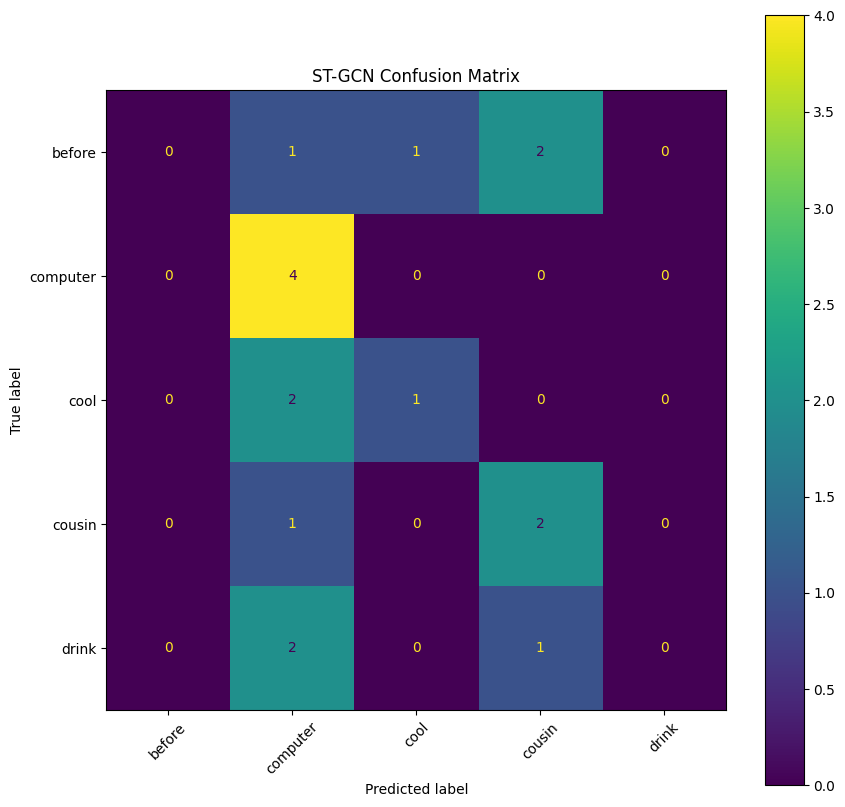

In [21]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("ST-GCN Confusion Matrix")
plt.show()

## 21. Save the ST-GCN model package

This saves:

- trained model weights
- label encoder
- scaler
- adjacency matrix
- metadata and metrics

The metadata file can be used later when creating a combined model comparison report.

In [22]:
stgcn_model_path = MODEL_DIR / "stgcn_wlasl_graph_model.pt"
stgcn_encoder_path = MODEL_DIR / "stgcn_label_encoder.joblib"
stgcn_scaler_path = MODEL_DIR / "stgcn_scaler.joblib"
stgcn_adjacency_path = MODEL_DIR / "stgcn_adjacency_matrix.npy"
stgcn_metadata_path = MODEL_DIR / "stgcn_metadata.json"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "num_classes": NUM_CLASSES,
        "num_graph_nodes": NUM_GRAPH_NODES,
        "num_coordinates": FEATURES_PER_NODE,
        "classes": list(label_encoder.classes_),
    },
    stgcn_model_path,
)

joblib.dump(label_encoder, stgcn_encoder_path)
joblib.dump(scaler, stgcn_scaler_path)
np.save(stgcn_adjacency_path, A_norm)

metadata = {
    "model": "Simple ST-GCN baseline",
    "dataset": DATASET_NAME,
    "selected_classes": list(label_encoder.classes_),
    "feature_type": "MediaPipe pose + left hand + right hand graph sequences",
    "sequence_length": int(MAX_FRAMES),
    "frame_stride": int(FRAME_STRIDE),
    "num_samples": int(len(y_labels)),
    "num_graph_nodes": int(NUM_GRAPH_NODES),
    "num_coordinates": int(FEATURES_PER_NODE),
    "accuracy": float(accuracy),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1": float(f1),
}

stgcn_metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved ST-GCN model:", stgcn_model_path)
print("Saved label encoder:", stgcn_encoder_path)
print("Saved scaler:", stgcn_scaler_path)
print("Saved adjacency matrix:", stgcn_adjacency_path)
print("Saved metadata:", stgcn_metadata_path)

Saved ST-GCN model: /workspace/dataset/ksl_project_data/models/stgcn_wlasl_graph_model.pt
Saved label encoder: /workspace/dataset/ksl_project_data/models/stgcn_label_encoder.joblib
Saved scaler: /workspace/dataset/ksl_project_data/models/stgcn_scaler.joblib
Saved adjacency matrix: /workspace/dataset/ksl_project_data/models/stgcn_adjacency_matrix.npy
Saved metadata: /workspace/dataset/ksl_project_data/models/stgcn_metadata.json
